## Subclassing API - Classification

In [1]:
import tensorflow as tf
from tensorflow import keras

## Data
(X_train, y_train), (X_test, y_test)=keras.datasets.fashion_mnist.load_data()
X_train=X_train.reshape(-1, 784).astype("float32")/255.0
X_test=X_test.reshape(-1, 784).astype("float32")/255.0


## Model

In [2]:
class FashionClassifier(keras.Model):
    def __init__(self):
        super().__init__()
        self.fc1=keras.layers.Dense(256, activation="relu")
        self.drop1=keras.layers.Dropout(0.3)
        self.fc2=keras.layers.Dense(128, activation="relu")
        self.drop2=keras.layers.Dropout(0.3)
        self.out=keras.layers.Dense(10, activation="softmax")
        
    def call(self, x, training=False):
        x=self.fc1(x)
        x=self.drop1(x, training=training)
        x=self.fc2(x)
        x=self.drop2(x, training=training)
        return self.out(x)
    

model=FashionClassifier()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [3]:
## Train
history=model.fit(
    X_train, y_train,
    epochs=30, 
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7765 - loss: 0.6301 - val_accuracy: 0.8397 - val_loss: 0.4285
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8416 - loss: 0.4408 - val_accuracy: 0.8613 - val_loss: 0.3779
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8544 - loss: 0.4021 - val_accuracy: 0.8688 - val_loss: 0.3603
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8638 - loss: 0.3755 - val_accuracy: 0.8662 - val_loss: 0.3587
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8686 - loss: 0.3601 - val_accuracy: 0.8703 - val_loss: 0.3423
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8738 - loss: 0.3428 - val_accuracy: 0.8792 - val_loss: 0.3267
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8768 - loss: 0.3359 - val_accuracy: 0.8783 - val_loss: 0.3261
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8810 - loss: 0.3255 - val_accuracy: 0.

In [4]:
# Evaulate

from sklearn.metrics import f1_score, precision_score, recall_score

loss, acc = model.evaluate(X_test, y_test, verbose=0)

print("Classification Report:")
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)
print(f"Precision: {precision_score(y_test, y_pred_classes, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_classes, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_classes, average='weighted'):.4f}")
print(f"Test accuracy: {acc:.4f}")

Classification Report:
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step
Precision: 0.8920
Recall: 0.8907
F1 Score: 0.8910
Test accuracy: 0.8907


Confusion Matrix:
[[807   2  12  25   5   0 142   0   7   0]
 [  2 975   1  16   2   0   3   0   1   0]
 [ 11   2 800   8 104   0  75   0   0   0]
 [ 21   8   6 908  28   0  26   0   3   0]
 [  0   1  78  33 832   0  55   0   1   0]
 [  0   0   0   0   0 949   0  26   1  24]
 [ 89   1  77  29  68   0 731   0   5   0]
 [  0   0   0   0   0   5   0 985   0  10]
 [  4   0   3   2   5   1   7   4 974   0]
 [  0   0   0   0   0   4   1  49   0 946]]


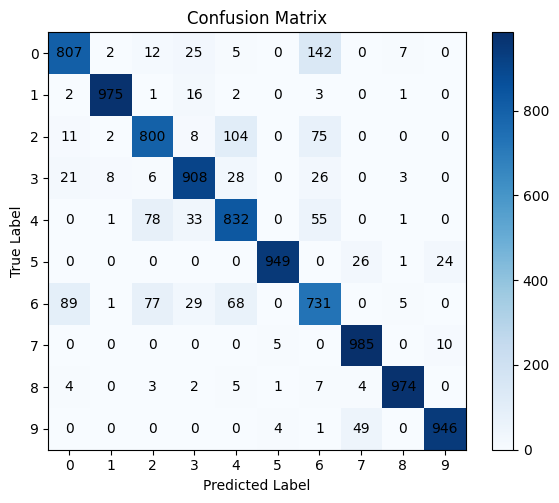

In [5]:
# confusion matrics

## Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

classes = np.unique(y_test)
plt.xticks(classes)
plt.yticks(classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Write numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center')

plt.tight_layout()
plt.show()